In [53]:
from scipy.io import loadmat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [54]:
# !wget http://ufldl.stanford.edu/housenumbers/train_32x32.mat
# !wget http://ufldl.stanford.edu/housenumbers/test_32x32.mat

In [55]:
data_train = loadmat("train_32x32.mat")
data_test = loadmat("test_32x32.mat")

## EDA

In [56]:
data_train

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Mon Dec  5 21:09:26 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[[[ 33,  84,  19, ...,  92, 190, 216],
          [ 30,  76,  54, ...,  78, 188, 217],
          [ 38,  59, 110, ..., 101, 191, 212]],
 
         [[ 15,  86,  20, ...,  94, 205, 221],
          [ 23,  73,  52, ...,  82, 203, 222],
          [ 19,  66, 111, ..., 105, 206, 217]],
 
         [[ 15,  77,  25, ..., 114, 220, 226],
          [ 17,  78,  57, ..., 101, 218, 227],
          [ 19,  56, 116, ..., 125, 220, 221]],
 
         ...,
 
         [[ 72,  90,  65, ..., 200, 229, 200],
          [ 65,  78, 144, ..., 201, 231, 199],
          [ 56,  69, 223, ..., 203, 224, 191]],
 
         [[ 82,  88,  78, ..., 192, 229, 193],
          [ 77,  77, 148, ..., 193, 229, 188],
          [ 57,  67, 218, ..., 195, 224, 182]],
 
         [[ 89,  88,  98, ..., 190, 229, 197],
          [ 79,  78, 158, ..., 191, 228, 189],
          [ 59,  66, 220, 

In [57]:
type(data_train)

dict

In [58]:
# Every dictionary has 3 attributes: .items(), .keys(), .values()
data_train.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

In [59]:
data_test.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

In [60]:
X_train = data_train['X']
X_test = data_test['X']

y_train = data_train['y']
y_test = data_test['y']


In [61]:
type(X_train)

numpy.ndarray

In [62]:
X_train.shape

(32, 32, 3, 73257)

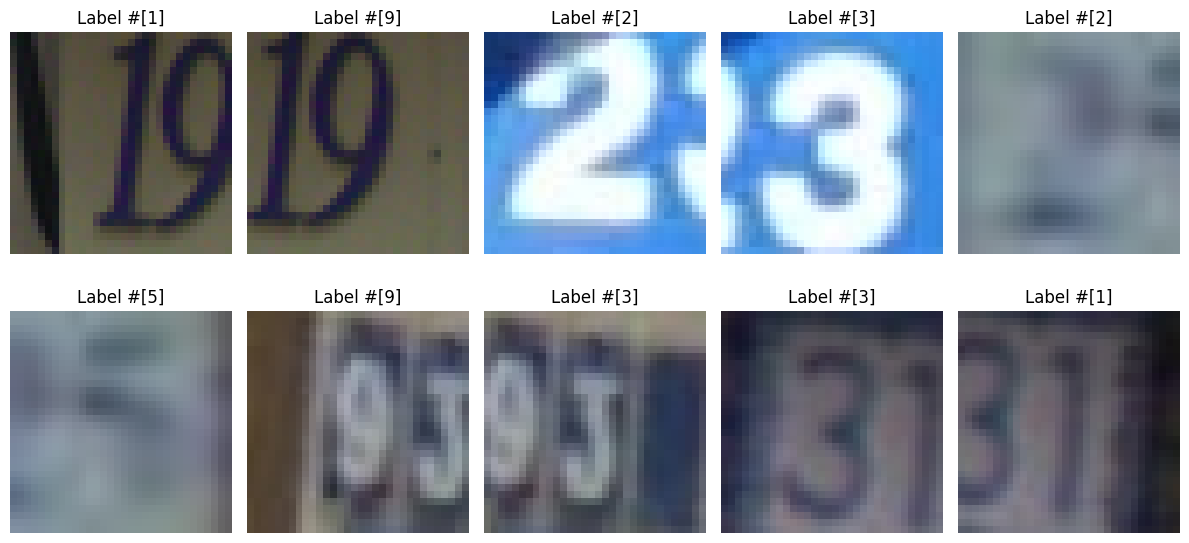

In [63]:
fig, axes = plt.subplots(2, 5, figsize=(12,6))
axes = axes.ravel() #flatten axes for easy indexing

for i in range(10):

    img = X_train[:, :, :, i]

    axes[i].imshow(img)
    axes[i].set_title(f"Label #{y_train[i]}")
    axes[i].axis("off") # remove ticks from axis

plt.tight_layout()
plt.show()

In [64]:
# Trun the previous code into function
def image_vis(X, y):
    fig, axes = plt.subplots(2, 5, figsize=(12,6))
    axes = axes.ravel() #flatten axes for easy indexing

    for i in range(10):

        img = X[:, :, :, i]

        axes[i].imshow(img)
        axes[i].set_title(f"Label #{y[i]}")
        axes[i].axis("off") # remove ticks from axis

    plt.tight_layout()
    plt.show()

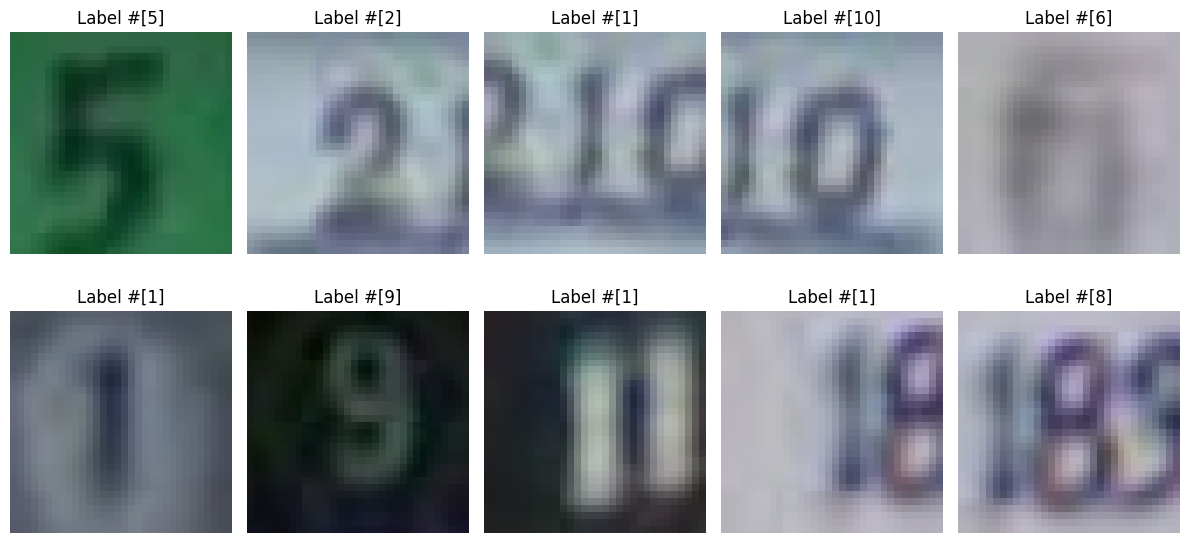

In [65]:
image_vis(X_test, y_test)

In [66]:
# check the y distribution to see if dataset is imbalanced

np.unique(y_train, return_counts=True)

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=uint8),
 array([13861, 10585,  8497,  7458,  6882,  5727,  5595,  5045,  4659,
         4948], dtype=int64))

In [67]:
unique_labels, counts = np.unique(y_train, return_counts=True)
train_label_dist =  dict(zip(unique_labels, counts))
train_label_dist

{1: 13861,
 2: 10585,
 3: 8497,
 4: 7458,
 5: 6882,
 6: 5727,
 7: 5595,
 8: 5045,
 9: 4659,
 10: 4948}

In [68]:
# Turn the previous code  to function
def label_dist(y):
    unique_labels, counts = np.unique(y_train, return_counts=True)
    return dict(zip(unique_labels, counts))

In [69]:
train_dist = label_dist(y_train)
test_dist = label_dist(y_test)

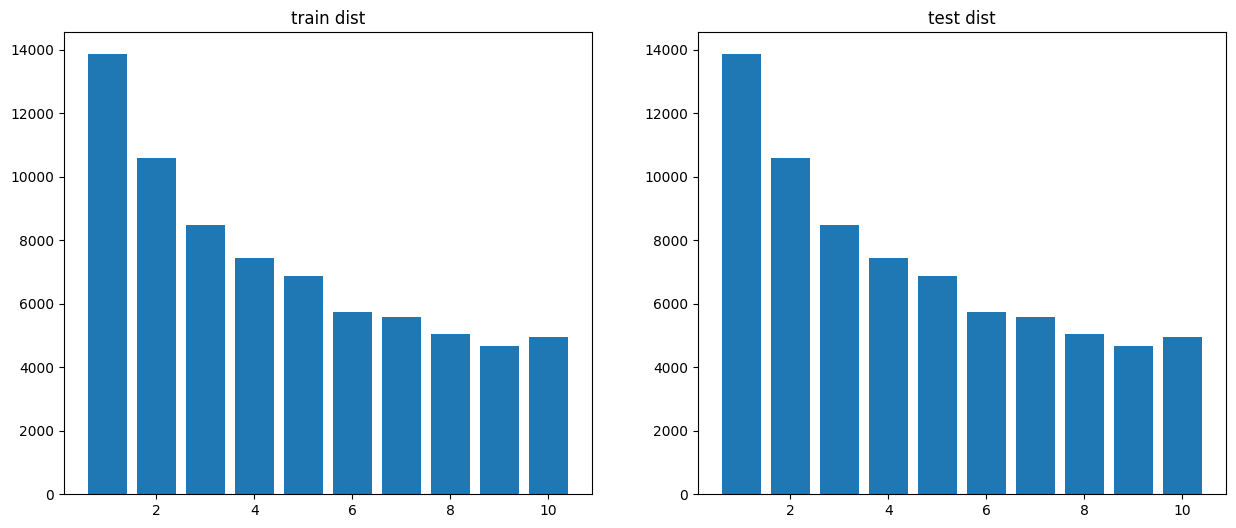

In [70]:
plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
plt.bar(train_dist.keys(), train_dist.values())
plt.title("train dist")
plt.subplot(1, 2, 2)
plt.bar(test_dist.keys(), test_dist.values())
plt.title("test dist")
plt.show()

## Preprocessing

In [71]:
X_train.min(), X_train.max()

(0, 255)

### Normalization

In [72]:
def normalizer(X):
    X = X / 255
    return X

In [73]:
X_train_norm = normalizer(X_train)
X_test_norm = normalizer(X_test)

In [74]:
X_train_norm

array([[[[0.12941176, 0.32941176, 0.0745098 , ..., 0.36078431,
          0.74509804, 0.84705882],
         [0.11764706, 0.29803922, 0.21176471, ..., 0.30588235,
          0.7372549 , 0.85098039],
         [0.14901961, 0.23137255, 0.43137255, ..., 0.39607843,
          0.74901961, 0.83137255]],

        [[0.05882353, 0.3372549 , 0.07843137, ..., 0.36862745,
          0.80392157, 0.86666667],
         [0.09019608, 0.28627451, 0.20392157, ..., 0.32156863,
          0.79607843, 0.87058824],
         [0.0745098 , 0.25882353, 0.43529412, ..., 0.41176471,
          0.80784314, 0.85098039]],

        [[0.05882353, 0.30196078, 0.09803922, ..., 0.44705882,
          0.8627451 , 0.88627451],
         [0.06666667, 0.30588235, 0.22352941, ..., 0.39607843,
          0.85490196, 0.89019608],
         [0.0745098 , 0.21960784, 0.45490196, ..., 0.49019608,
          0.8627451 , 0.86666667]],

        ...,

        [[0.28235294, 0.35294118, 0.25490196, ..., 0.78431373,
          0.89803922, 0.78431373],


In [75]:
np.shape(X_train_norm)

(32, 32, 3, 73257)

In [76]:
# gray_scale
def convert_gray(X):
    return np.mean(X, axis=2, keepdims=True)

In [77]:
X_train_norm_gray = convert_gray(X_train_norm)
X_test_norm_gray = convert_gray(X_test_norm)

In [78]:
X_train_norm_gray.shape, X_test_norm_gray.shape

((32, 32, 1, 73257), (32, 32, 1, 26032))

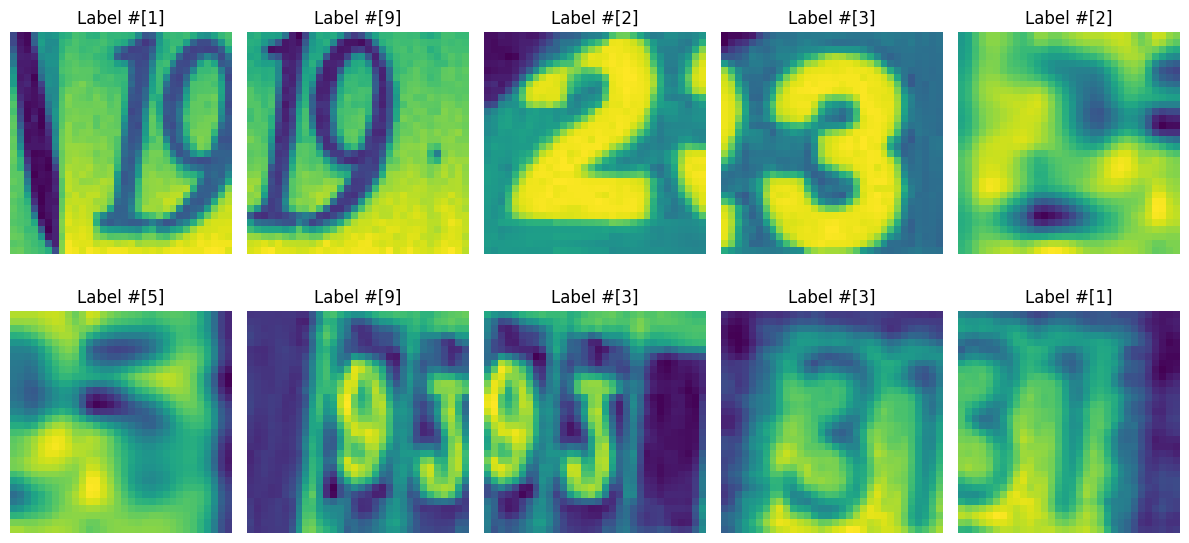

In [79]:
image_vis(X_train_norm_gray, y_train)

In [80]:
# Reshape to prepare inputs
def reshape(X):
  return X.transpose(3, 0, 1, 2).reshape(X.shape[3], -1)

In [81]:
X_tr = reshape(X_train_norm_gray)
X_ts = reshape(X_test_norm_gray)

In [82]:
X_tr.shape, X_ts.shape

((73257, 1024), (26032, 1024))

In [83]:
X_tr_rgb = reshape(X_train_norm)
X_ts_rgb = reshape(X_test_norm)

In [84]:
X_tr_rgb.shape, X_ts_rgb.shape

((73257, 3072), (26032, 3072))

## Training

In [85]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(max_depth=20, n_estimators=100)
rf_clf.fit(X_tr, y_train)

c:\Users\Soheil\Desktop\New folder\SVHN\venv\lib\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=20)

In [86]:
y_pred = rf_clf.predict(X_ts)

In [87]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.6937615242778119

In [88]:
from sklearn.decomposition import PCA

pca = PCA()
X_tr_pca = pca.fit_transform(X_tr)
X_ts_pca = pca.transform(X_ts)

In [89]:
X_tr_pca.shape, X_ts_pca.shape

((73257, 1024), (26032, 1024))

In [90]:
variances = pca.explained_variance_ratio_
variances

array([6.06703902e-01, 5.97587652e-02, 4.87212300e-02, ...,
       4.43992325e-08, 4.25845412e-08, 4.20103008e-08])

In [91]:
# cumulative percentage of components' importance
cum_variances = np.cumsum(variances)
cum_variances

array([0.6067039 , 0.66646267, 0.7151839 , ..., 0.99999992, 0.99999996,
       1.        ])

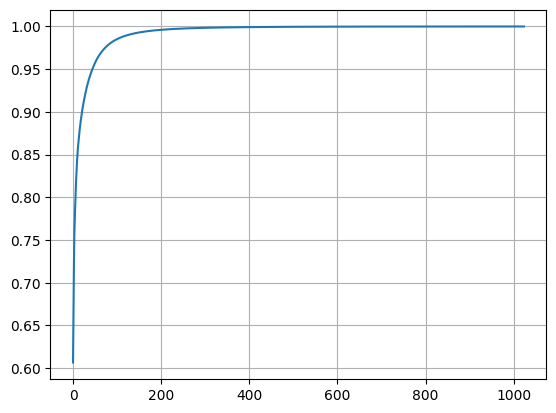

In [92]:
plt.plot(cum_variances)
plt.grid()

In [93]:
cum_variances > 0.9

array([False, False, False, ...,  True,  True,  True])

In [94]:
np.argmax(cum_variances > 0.9)

21

In [95]:
component_90 = np.argmax(cum_variances > 0.9) + 1
component_90

22

In [96]:
pca_90 = PCA(n_components=component_90)
X_tr_pca_90 = pca_90.fit_transform(X_tr)
X_ts_pca_90 = pca_90.transform(X_ts)

In [97]:
rf_clf = RandomForestClassifier(max_depth=20, n_estimators=100)
rf_clf.fit(X_tr_pca_90, y_train)

c:\Users\Soheil\Desktop\New folder\SVHN\venv\lib\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=20)

In [98]:
y_pred_90 = rf_clf.predict(X_ts_pca_90)
accuracy_score(y_test, y_pred_90)

0.5936923786109404

In [101]:
np.unique(y_train)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=uint8)

In [102]:
np.unique(y_test)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=uint8)

In [103]:
# Replace 10s with 0s
y_train_0 = np.where(y_train==10, 0, y_train)
y_test_0 = np.where(y_test==10, 0, y_test)

In [109]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200)
xgb.fit(X_tr_pca_90, y_train_0)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [110]:
y_pred_90_xgb = xgb.predict(X_ts_pca_90)

accuracy_score(y_test_0, y_pred_90_xgb)

0.65069913952059